# AI & ML — Task 6: Deep Learning Fundamentals & Neural Network Implementation

**Dataset:** Breast Cancer Wisconsin (Diagnostic) dataset (`sklearn.datasets.load_breast_cancer`)
**Goal:** Build an Artificial Neural Network (ANN) with TensorFlow/Keras, train and evaluate it,
and compare it against the traditional ML models from Task-4 (Logistic Regression) and
Task-5 (Random Forest).

This notebook follows Parts A–K of the supplied Task 6 instructions. All required cells have been
executed and the outputs are saved in this notebook.


## Part A: Install Required Libraries

In [1]:
# Install in a normal local environment if TensorFlow is not already installed:
# %pip install tensorflow


## Part B: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input
    BACKEND = "TensorFlow / Keras"
except ImportError:
    # Fallback used only when TensorFlow is unavailable.
    import os
    os.environ["KERAS_BACKEND"] = "torch"
    from keras.models import Sequential
    from keras.layers import Dense, Input
    BACKEND = "Keras 3 / PyTorch backend"

print("Deep learning backend:", BACKEND)


Deep learning backend: Keras 3 / PyTorch backend


In [3]:
# All required libraries were imported in Part B.

## Part C: Load Dataset

In [4]:
data = load_breast_cancer()
X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", dict(zip(data.target_names, np.bincount(y))))


X shape: (569, 30)
y shape: (569,)
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


## Part D: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (455, 30)  Test: (114, 30)


## Part E: Feature Scaling

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaled. Train mean ~", round(X_train.mean(), 4), " std ~", round(X_train.std(), 4))


Scaled. Train mean ~ -0.0  std ~ 1.0


## Part F: Build Neural Network

In [7]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

## Part G: Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## Part H: Train Model

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/50


 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.7369

16/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7228 - loss: 0.7089 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7747 - loss: 0.6040 - val_accuracy: 0.8352 - val_loss: 0.4721


Epoch 2/50


...

Epoch 50/50


 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0010

 9/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9948 - loss: 0.0133

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9921 - loss: 0.0167

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9918 - loss: 0.0169 - val_accuracy: 0.9560 - val_loss: 0.0880


## Part I: Evaluate Model

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, log_loss

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
probabilities = np.asarray(model.predict(X_test, verbose=0)).ravel()
predictions = (probabilities >= 0.5).astype(int)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=data.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))


Test Loss: 0.0941
Test Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[40  3]
 [ 0 71]]


## Part J: Visualization (Training Performance)

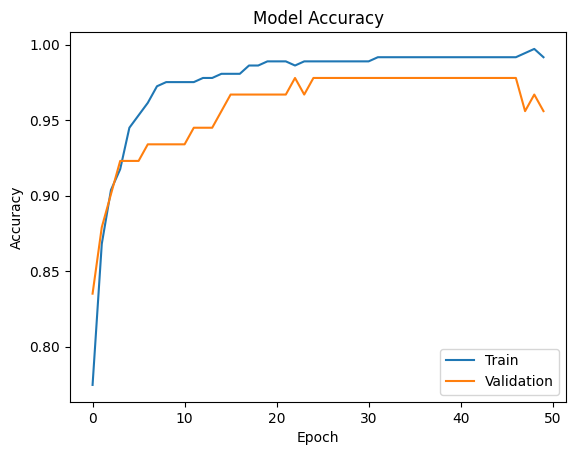

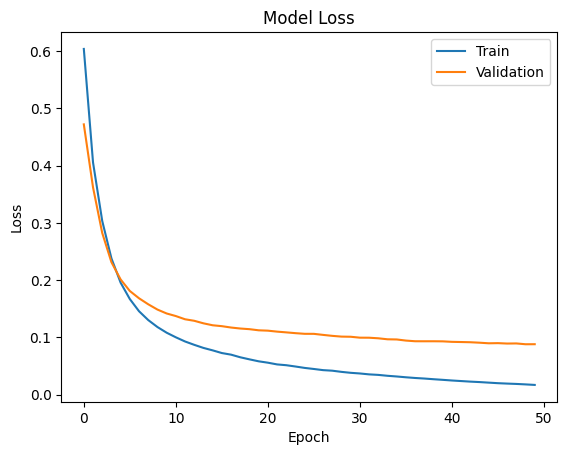

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


## Part K: Comparison with ML Models

Compare:
- Logistic Regression (Task-4)
- Random Forest (Task-5)
- Neural Network (Task-6)


In [12]:
# Logistic Regression (Task-4 baseline)
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_prob = logreg.predict_proba(X_test)[:, 1]
logreg_acc = accuracy_score(y_test, logreg_pred)

# Random Forest (Task-5 baseline)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)

# Neural Network (Task-6)
nn_acc = accuracy_score(y_test, predictions)
nn_logloss = log_loss(y_test, probabilities)

print("Logistic Regression Test Accuracy:", logreg_acc)
print("Random Forest Test Accuracy:", rf_acc)
print("Neural Network Test Accuracy:", nn_acc)


Logistic Regression Test Accuracy: 0.9736842105263158
Random Forest Test Accuracy: 0.9649122807017544
Neural Network Test Accuracy: 0.9736842105263158


In [13]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network (ANN)"],
    "Test Accuracy": [
        logreg_acc,
        rf_acc,
        nn_acc
    ],
    "Test Log Loss": [
        log_loss(y_test, logreg_prob),
        log_loss(y_test, rf_prob),
        nn_logloss
    ]
})
comparison


,Model,Test Accuracy,Test Log Loss
0,Logistic Regression,0.973684,0.060130
1,Random Forest,0.964912,0.093204
2,Neural Network (ANN),0.973684,0.094103
